<a href="https://colab.research.google.com/github/OutisAyo/council-classifier-/blob/main/notebooks/12_priority_model_comparison.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Machine Learning for Automated Classification and Prioritisation of Local Council Service Requests in the UK
## Notebook 12  Model Comparison and Final Selection (Priority Prediction)

**Author:** Fashina Fuad Ayomide  
**MSc Data Science, University of South Wales**

This notebook compares the four classification models built in Notebooks 08-11 for priority prediction, and documents the diagnostic findings on urgency vocabulary before proceeding to targeted enhancements.

## Mounting Google Drive

In [2]:
from google.colab import drive
drive.mount ('/content/drive')

Mounted at /content/drive


## Importing the libraries

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

## Loading the comparison results

In [4]:
results_path = '/content/drive/MyDrive/council-classifier/processed/priority_model_results.csv'
results_df = pd.read_csv(results_path)
results_df

,model,accuracy,f1_macro,f1_weighted
0,Naive Bayes,0.627801,0.587242,0.625258
1,Logistic Regression,0.657147,0.607315,0.647002
2,Random Forest,0.658857,0.609522,0.648884
3,XGBoost,0.658896,0.607438,0.646674


## Visualising model performance

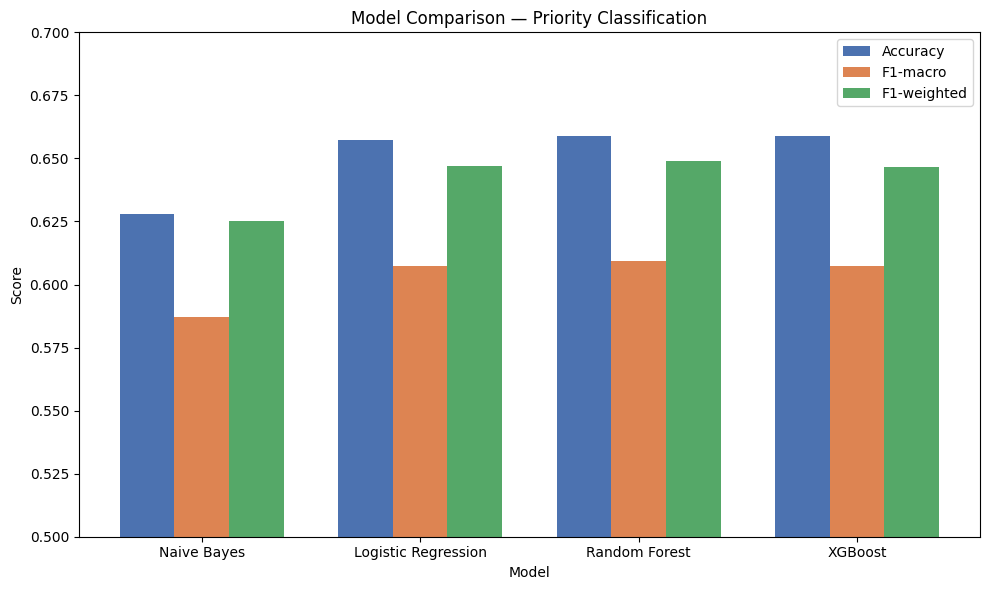

In [5]:
fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(results_df))
width = 0.25

ax.bar(x - width, results_df['accuracy'], width, label='Accuracy', color='#4C72B0')
ax.bar(x, results_df['f1_macro'], width, label='F1-macro', color='#DD8452')
ax.bar(x + width, results_df['f1_weighted'], width, label='F1-weighted', color='#55A868')

ax.set_xlabel('Model')
ax.set_ylabel('Score')
ax.set_title('Model Comparison — Priority Classification')
ax.set_xticks(x)
ax.set_xticklabels(results_df['model'])
ax.set_ylim(0.5, 0.7)
ax.legend()
plt.tight_layout()
plt.show()

## Identifying the best model by F1-macro

In [6]:
best_model_row = results_df.loc[results_df['f1_macro'].idxmax()]
print("Best performing model (by F1-macro):")
print(best_model_row)

Best performing model (by F1-macro):
model          Random Forest
accuracy            0.658857
f1_macro            0.609522
f1_weighted         0.648884
Name: 2, dtype: object


## Summary of findings

- All four models converge around 63-66% accuracy and 0.59-0.61 F1-macro, a stark contrast to department classification's 99%+ scores
- **Random Forest and Logistic Regression are tied** for best F1-macro (0.61), with XGBoost and Random Forest essentially indistinguishable in practice
- **HIGH-priority recall is consistently limited to 33-34% across all four algorithms**, indicating the ceiling is driven by feature availability rather than model choice
- Diagnostic analysis of feature importance found that explicit urgency vocabulary ("urgent", "dangerous", "hazard") is present but contributes minimal predictive weight, while words like "emergency", "immediate", "risk", and "severe" do not appear in the vocabulary at all
- This suggests the category and complaint type codes, being standardised staff-assigned classifications, largely omit the urgency signals likely present in original citizen-submitted complaint text
- **Random Forest is selected as the base priority classification model**, with subsequent experiments (class weighting, TF-IDF, n-grams, temporal features) explored to address the identified limitations

## Saving the base priority model

We save this as the baseline priority pipeline. A separate enhanced version will be built and compared in the next notebook.

In [10]:
import joblib
import os
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.ensemble import RandomForestClassifier

processed_dir = '/content/drive/MyDrive/council-classifier/processed'
models_dir = '/content/drive/MyDrive/council-classifier/models'
os.makedirs(models_dir, exist_ok=True)

X_train = np.load(f'{processed_dir}/X_train.npy', allow_pickle=True)
y_prio_train = np.load(f'{processed_dir}/y_prio_train.npy', allow_pickle=True)

priority_pipeline_baseline = Pipeline([
    ('vectorizer', CountVectorizer(max_features=1500)),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=0, n_jobs=-1))
])

priority_pipeline_baseline.fit(X_train, y_prio_train)

joblib.dump(priority_pipeline_baseline, f'{models_dir}/priority_pipeline_baseline_rf.pkl')
print("Baseline priority pipeline saved to:", models_dir)

Baseline priority pipeline saved to: /content/drive/MyDrive/council-classifier/models
